# Time Series Transformer for P(RUL > 2 days) Classification

**Task:** Binary classification of aircraft maintenance risk using sensor time series.

**Inputs from feature engineering pipeline:** `sequences.npy`, `seq_indices.npy`, `labels.csv`

**Model:** Transformer Encoder (PyTorch)

---

## How to use this notebook

1. **Run the feature engineering notebook first** (in the same Kaggle session). It saves outputs to `/kaggle/working/`.
2. **Run this notebook second.** It loads those outputs and trains the Transformer.
3. **Toggle `RUN_MODE`** in cell 0.1 between `'subset'` (50 flights for testing) and `'full'` (all flights for real training).
4. **Toggle `TARGET_VARIABLE`** between `'rul_2d'`, `'rul_5d'`, or `'rul_10d'` to switch target.

---

## Pipeline Overview

1. Configuration and Data Loading (reads teammate's outputs)
2. Build Attention Mask + Train/Val/Test Setup
3. PyTorch Dataset and DataLoader
4. Model Architecture (Transformer Encoder)
5. Training Setup (loss, optimizer, scheduler)
6. Training Loop with composite scoring
7. Evaluation (all 6 metrics + confusion matrix)
8. Error Analysis (false neg/pos breakdown)
9. Attention Visualization
10. Save artifacts for handoff


Check GPU memory before training

In [15]:
import torch
import gc

# Delete any large variables from previous runs
gc.collect()

# Empty PyTorch's CUDA cache
torch.cuda.empty_cache()

# Check memory status
if torch.cuda.is_available():
    print(f'Memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB')
    print(f'Memory reserved : {torch.cuda.memory_reserved() / 1e9:.2f} GB')

Memory allocated: 0.08 GB
Memory reserved : 0.12 GB


---
## Step 1. Configuration and Data Loading

### 1.1 Configuration

**Purpose:** Centralize all knobs. To switch between subset/full or change target variable, only edit this cell.


In [16]:
import os
import numpy as np
import pandas as pd
import torch

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# =====================================================================
# RUN MODE -- TOGGLE THIS
# =====================================================================
RUN_MODE = 'full'   # 'subset' for fast pipeline test (500 flights)
                      # 'full'   for real run on all flights

SUBSET_PER_CLASS = 250  # used only in 'subset' mode (250 + 250 = 500 flights)

TARGET_VARIABLE = 'rul_5d'   # 'rul_2d' (primary), 'rul_5d', or 'rul_10d'

# =====================================================================
# MODEL HYPERPARAMETERS
# =====================================================================
SEQ_LEN     = 9212   
COMP_SEQ_LEN = 512

N_CHANNELS  = 15       
N_CLASSES   = 2

BATCH_SIZE = 2     # adjust based on GPU memory; 8 is conservative for SEQ_LEN=9212
WEIGHT_DECAY = 1e-4

# Experiment
D_MODEL = 256
N_HEAD  = 8
NUM_LAYERS = 4
DIM_FEEDFORWARD = 1024
LR = 3e-5
DROPOUT = 0.1
N_EPOCHS   = 10    # full run; reduce to 5 for quick test in subset mode

# =====================================================================
# COMPOSITE SCORE WEIGHTS (for best-model selection during training)
# =====================================================================
BEST_METRIC_TO_TRACK = 'val_pr_auc'

# =====================================================================
# FILE PATHS (from feature engineering file, same Kaggle session)
# =====================================================================
DATA_DIR = '/kaggle/input/datasets/kimberlybertoli/aircraft-pipeline'
SEQUENCES   = os.path.join(DATA_DIR, 'sequences.npy')
SEQ_INDICES = os.path.join(DATA_DIR, 'seq_indices.npy')
LABELS_CSV  = os.path.join(DATA_DIR, 'labels.csv')

# Channel names (for plots, in the order teammate stored them)
CHANNEL_NAMES = ['volt1', 'amp1', 'FQtyL', 'FQtyR', 'E1 FFlow',
                 'E1 OilT', 'E1 OilP', 'E1 RPM', 'E1 CHT1', 'E1 EGT1',
                 'OAT', 'IAS', 'VSpd', 'NormAc', 'AltMSL']

print(f'RUN_MODE        : {RUN_MODE}')
print(f'TARGET_VARIABLE : {TARGET_VARIABLE}')
print(f'SEQ_LEN         : {SEQ_LEN}')
print(f'N_CHANNELS      : {N_CHANNELS}')
print(f'BATCH_SIZE      : {BATCH_SIZE}')
print(f'N_EPOCHS        : {N_EPOCHS}')


RUN_MODE        : full
TARGET_VARIABLE : rul_5d
SEQ_LEN         : 9212
N_CHANNELS      : 15
BATCH_SIZE      : 2
N_EPOCHS        : 10


### 1.2 Load Engineering's Output Files

**Purpose:** Memory-map the sequences file (5.4 GB, do not load into RAM all at once), read labels CSV, align them via Master Index.


In [17]:
# Memory-map sequences (does NOT load into RAM until accessed)
sequences = np.load(SEQUENCES, mmap_mode='r')
seq_indices = np.load(SEQ_INDICES)
labels_df = pd.read_csv(LABELS_CSV, index_col='Master Index')

print(f'sequences shape : {sequences.shape}  dtype={sequences.dtype}')
print(f'seq_indices     : {len(seq_indices):,} flights')
print(f'labels rows     : {len(labels_df):,}')

# Align labels to sequences via Master Index
y_full     = labels_df.loc[seq_indices, TARGET_VARIABLE].values.astype(np.int64)
split_full = labels_df.loc[seq_indices, 'split'].values

print(f'\nTarget variable: {TARGET_VARIABLE}')
print(f'Class distribution:')
print(f'  Class 0 (at risk) : {(y_full == 0).sum():,}')
print(f'  Class 1 (safe)    : {(y_full == 1).sum():,}')
print(f'\nSplit distribution:')
for sp in ['train', 'val', 'test']:
    print(f'  {sp:5s}: {(split_full == sp).sum():,}')


sequences shape : (19540, 9212, 15)  dtype=float16
seq_indices     : 19,540 flights
labels rows     : 19,540

Target variable: rul_5d
Class distribution:
  Class 0 (at risk) : 10,119
  Class 1 (safe)    : 9,421

Split distribution:
  train: 13,678
  val  : 2,931
  test : 2,931


### 1.3 Apply Subset Filter (for quick pipeline testing)

**Purpose:** When `RUN_MODE='subset'`, select 500 flights from each class for fast testing. When `RUN_MODE='full'`, use all flights.


In [18]:
if RUN_MODE == 'subset':
    rng = np.random.default_rng(SEED)
    subset_positions = []
    for cls in [0, 1]:
        pool = np.where(y_full == cls)[0]
        picked = rng.choice(pool, size=min(SUBSET_PER_CLASS, len(pool)), replace=False)
        subset_positions.extend(picked)
    subset_positions = np.array(sorted(subset_positions))
    
    # Apply subset
    seq_indices_used = seq_indices[subset_positions]
    y               = y_full[subset_positions]
    split_array     = split_full[subset_positions]
    sequence_positions = subset_positions  # positions into the memmap
    
    print(f'SUBSET MODE: using {len(subset_positions)} flights ({SUBSET_PER_CLASS} per class)')
    
elif RUN_MODE == 'full':
    seq_indices_used = seq_indices
    y               = y_full
    split_array     = split_full
    sequence_positions = np.arange(len(seq_indices))
    
    print(f'FULL MODE: using all {len(seq_indices):,} flights')

else:
    raise ValueError(f'Unknown RUN_MODE: {RUN_MODE}')

print(f'\nFinal class distribution: {np.bincount(y)}')
print(f'Final split distribution:')
for sp in ['train', 'val', 'test']:
    n = (split_array == sp).sum()
    n_class0 = ((split_array == sp) & (y == 0)).sum()
    n_class1 = ((split_array == sp) & (y == 1)).sum()
    print(f'  {sp:5s}: {n:,}  (class0: {n_class0}, class1: {n_class1})')


FULL MODE: using all 19,540 flights

Final class distribution: [10119  9421]
Final split distribution:
  train: 13,678  (class0: 7101, class1: 6577)
  val  : 2,931  (class0: 1509, class1: 1422)
  test : 2,931  (class0: 1509, class1: 1422)


---
## Step 2. Build Attention Mask and Split Indices

### 2.1 Compute Attention Mask from Left-Padding Pattern

**Purpose:** Teammate's pipeline LEFT-pads sequences. Positions where all 15 channels are zero on the left side are padding. The mask marks 1 for real timesteps and 0 for padded ones.


In [19]:
def compute_mask_for_flight(seq_arr):
    """Given (T, C) array, return (T,) mask where 1=real, 0=left-padded.
    
    Left padding pattern: leading rows where ALL channels are exactly 0.
    Once we hit the first non-zero row, everything after is real.
    """
    nonzero_per_row = (seq_arr != 0).any(axis=1)  # (T,) bool
    if not nonzero_per_row.any():
        return np.zeros(seq_arr.shape[0], dtype=np.float32)
    first_real = np.argmax(nonzero_per_row)  # first True position
    mask = np.zeros(seq_arr.shape[0], dtype=np.float32)
    mask[first_real:] = 1.0
    return mask


# Build masks for all flights in our working set
# Note: for memory efficiency, we'll build masks lazily inside the Dataset
# For now, compute mask lengths for a sanity check
sample_check = min(5, len(sequence_positions))
print(f'Sanity check on first {sample_check} flights:')
for i in range(sample_check):
    pos = sequence_positions[i]
    seq = np.array(sequences[pos], dtype=np.float32)
    m = compute_mask_for_flight(seq)
    real_len = int(m.sum())
    print(f'  Flight {seq_indices_used[i]}: real length = {real_len:,}, '
          f'padded steps = {SEQ_LEN - real_len:,}')


Sanity check on first 5 flights:
  Flight 1: real length = 4,723, padded steps = 4,489
  Flight 2: real length = 4,649, padded steps = 4,563
  Flight 7: real length = 3,482, padded steps = 5,730
  Flight 9: real length = 4,979, padded steps = 4,233
  Flight 11: real length = 5,204, padded steps = 4,008


### 2.2 Build Split Index Arrays

**Purpose:** Convert teammate's split labels into integer index arrays for the training loop.


In [20]:
idx_train = np.where(split_array == 'train')[0]
idx_val   = np.where(split_array == 'val')[0]
idx_test  = np.where(split_array == 'test')[0]

print(f'idx_train: {len(idx_train):,}')
print(f'idx_val  : {len(idx_val):,}')
print(f'idx_test : {len(idx_test):,}')

# Class balance per split
for name, idx in [('train', idx_train), ('val', idx_val), ('test', idx_test)]:
    if len(idx) > 0:
        bal = np.bincount(y[idx])
        print(f'  {name} class balance: {bal}')


idx_train: 13,678
idx_val  : 2,931
idx_test : 2,931
  train class balance: [7101 6577]
  val class balance: [1509 1422]
  test class balance: [1509 1422]


---
## Step 3. PyTorch Dataset and DataLoader

**Purpose:** Wrap the memory-mapped sequences in a PyTorch Dataset. Each `__getitem__` loads one flight from disk on demand (avoiding loading 5.4 GB into RAM), converts to float32, computes the attention mask.


In [21]:
import random
from torch.utils.data import Dataset, DataLoader

# ─── Temporal Augmentations ───
P_AUG = 0.4

def temporal_cutout(seq, p=P_AUG, min_len=64, max_len=512, channel_prob=0.3):
    if random.random() > p:
        return seq
    seq = seq.copy()
    T, C = seq.shape
    seg_len = random.randint(min_len, min(max_len, T))
    start = random.randint(0, T - seg_len)
    for ch in range(C):
        if random.random() < channel_prob:
            seq[start:start + seg_len, ch] = 0.0
    return seq

def temporal_cutmix(seq, other_seq, p=P_AUG, min_len=64, max_len=512, channel_prob=0.3):
    if random.random() > p:
        return seq
    seq = seq.copy()
    T, C = seq.shape
    seg_len = random.randint(min_len, min(max_len, T))
    start1 = random.randint(0, T - seg_len)
    start2 = random.randint(0, T - seg_len)
    for ch in range(C):
        if random.random() < channel_prob:
            seq[start1:start1 + seg_len, ch] = other_seq[start2:start2 + seg_len, ch]
    return seq

def temporal_mixup(seq, other_seq, p=P_AUG, channel_prob=0.4, m_range=(0.6, 0.9)):
    if random.random() > p:
        return seq
    seq = seq.copy()
    m = random.uniform(*m_range)
    for ch in range(seq.shape[1]):
        if random.random() < channel_prob:
            seq[:, ch] = seq[:, ch] * m + other_seq[:, ch] * (1 - m)
    return seq


class FlightDataset(Dataset):
    def __init__(self, sequences_mmap, sequence_positions, y, indices_into_y,
                 augment=False):
        self.sequences = sequences_mmap
        self.seq_positions = sequence_positions
        self.y = y
        self.indices = indices_into_y
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        local_pos = self.indices[i]
        mmap_pos = self.seq_positions[local_pos]
        seq = np.array(self.sequences[mmap_pos], dtype=np.float32)

        # Apply augmentations (training only)
        if self.augment:
            other_i = random.randint(0, len(self.indices) - 1)
            other_pos = self.seq_positions[self.indices[other_i]]
            other_seq = np.array(self.sequences[other_pos], dtype=np.float32)
            seq = temporal_cutout(seq)
            seq = temporal_cutmix(seq, other_seq)
            seq = temporal_mixup(seq, other_seq)

        # Compute mask
        nonzero = (seq != 0).any(axis=1)
        if nonzero.any():
            first_real = np.argmax(nonzero)
            mask = np.zeros(seq.shape[0], dtype=np.float32)
            mask[first_real:] = 1.0
        else:
            mask = np.zeros(seq.shape[0], dtype=np.float32)

        label = self.y[local_pos]
        return (torch.from_numpy(seq).float(),
                torch.from_numpy(mask).float(),
                torch.tensor(label, dtype=torch.long))


train_ds = FlightDataset(sequences, sequence_positions, y, idx_train, augment=True)   # ← augment!
val_ds   = FlightDataset(sequences, sequence_positions, y, idx_val,   augment=False)
test_ds  = FlightDataset(sequences, sequence_positions, y, idx_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

xb, mb, yb = next(iter(train_loader))
print(f'Batch X    : {xb.shape}  dtype={xb.dtype}')
print(f'Batch mask : {mb.shape}  dtype={mb.dtype}')
print(f'Batch y    : {yb.shape}  values={yb.tolist()}')

Batch X    : torch.Size([2, 9212, 15])  dtype=torch.float32
Batch mask : torch.Size([2, 9212])  dtype=torch.float32
Batch y    : torch.Size([2])  values=[0, 0]


---
## Step 4. Model Architecture

### 4.1 Positional Encoding

**Purpose:** Sinusoidal positional encoding gives the model awareness of timestep position. Parameter-free, generalizes to any sequence length.


In [22]:
import torch
import torch.nn as nn
import math

class TimeSeriesTransformer(nn.Module):
    def __init__(self, n_channels=15, d_model=128, n_head=4, num_layers=2,
                 dim_feedforward=512, dropout=0.1):
        super().__init__()

        # 1. 1D Convolutional Front-End (Conv-MHSA style)
        self.conv_frontend = nn.Sequential(
            nn.Conv1d(n_channels, d_model // 2, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(d_model // 2),
            nn.GELU(),                        # FIX: was ReLU
            nn.Dropout(dropout),
            nn.Conv1d(d_model // 2, d_model, kernel_size=5, stride=4, padding=2),
            nn.BatchNorm1d(d_model),
            nn.GELU(),                        # FIX: was ReLU
            nn.Dropout(dropout)
        )

        # 2. Learnable Positional Encoding
        self.pos_encoder = nn.Parameter(torch.randn(1, 2000, d_model) * 0.02)

        # 3. Transformer Encoder Block
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_head,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu'                 # FIX: match conv front-end
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 4. Output Head
        self.norm = nn.LayerNorm(d_model)     # FIX: added
        self.fc_out = nn.Linear(d_model, 2)

    def forward(self, x, mask=None):
        # Conv1d: [batch, seq, channels] → [batch, channels, seq]
        x = x.transpose(1, 2)
        x = self.conv_frontend(x)
        x = x.transpose(1, 2)
        batch_size, reduced_seq, d_features = x.shape

        # Add positional encoding
        x = x + self.pos_encoder[:, :reduced_seq, :]

        # Downsample mask and apply to transformer
        if mask is not None:
            downsampled_mask = nn.functional.interpolate(
                mask.unsqueeze(1).float(),
                size=reduced_seq,
                mode='nearest'
            ).squeeze(1)

            src_key_padding_mask = (downsampled_mask == 0.0)
            x = self.transformer_encoder(x, src_key_padding_mask=src_key_padding_mask)

            # FIX: Masked mean pooling (don't average over padding)
            mask_exp = downsampled_mask.unsqueeze(-1)
            x = (x * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1e-6)
        else:
            x = self.transformer_encoder(x)
            x = torch.mean(x, dim=1)

        x = self.norm(x)                     # FIX: added
        logits = self.fc_out(x)
        return logits

### 4.2 Transformer Classifier

**Purpose:** Projects 15 sensor channels into d_model embedding, adds positional encoding, runs through Transformer encoder, applies masked mean pooling, outputs 2 class logits.


In [23]:
print("Initializing Convolutional Transformer model...")
model = TimeSeriesTransformer(
    n_channels=N_CHANNELS,
    d_model=D_MODEL,
    n_head=N_HEAD,
    num_layers=NUM_LAYERS,       
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print("\nRunning structural pipeline shape check...")
dummy_input = torch.randn(2, 4000, 15).to(device)
dummy_mask = torch.ones(2, 4000).to(device)
dummy_mask[0, 3500:] = 0.0

with torch.no_grad():
    dummy_output = model(dummy_input, mask=dummy_mask)

print(f"Input Data Shape     : {dummy_input.shape}")
print(f"Input Mask Shape     : {dummy_mask.shape}")
print(f"Output Logits Shape  : {dummy_output.shape} (Successfully verified!)")
print(f"\nTotal params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device      : {device}")
print("\nModel pipeline structure matches requirements. Ready for training loops.")

Initializing Convolutional Transformer model...

Running structural pipeline shape check...
Input Data Shape     : torch.Size([2, 4000, 15])
Input Mask Shape     : torch.Size([2, 4000])
Output Logits Shape  : torch.Size([2, 2]) (Successfully verified!)

Total params: 3,850,498
Device      : cuda

Model pipeline structure matches requirements. Ready for training loops.


---
## Step 5. Training Setup

**Purpose:** Class-weighted cross-entropy (handles imbalance), AdamW optimizer. Defines the evaluation function used during training and at test time.


In [24]:
from torch.optim import AdamW

# Class weights from training labels
class_counts = np.bincount(y[idx_train], minlength=N_CLASSES)
class_weights = torch.tensor(
    len(idx_train) / (N_CLASSES * np.maximum(class_counts, 1)),
    dtype=torch.float32, device=device
)
print(f'Class counts (train): {class_counts}')
print(f'Class weights        : {class_weights.cpu().numpy()}')

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


Class counts (train): [7101 6577]
Class weights        : [0.9631038 1.0398358]


### 5.1 Evaluation Function (all 6 metrics + inference time)

**Purpose:** Compute Recall, Precision, F1-macro, ROC-AUC, PR-AUC, Confusion Matrix, and inference time per flight on any dataloader.


In [25]:
import time
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                              roc_auc_score, average_precision_score, confusion_matrix)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    start = time.time()
    total = 0

    for xb, mb, yb in loader:
        xb, mb, yb = xb.to(device), mb.to(device), yb.to(device)
        logits = model(xb, mask=mb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        probs = F.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        total += xb.size(0)

    elapsed = time.time() - start
    inference_ms = elapsed / max(total, 1) * 1000

    avg_loss = total_loss / max(len(loader.dataset), 1)
    acc      = accuracy_score(all_labels, all_preds)
    recall_per_class    = recall_score(all_labels, all_preds, average=None, zero_division=0)
    recall_macro        = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    precision_per_class = precision_score(all_labels, all_preds, average=None, zero_division=0)
    precision_macro     = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_macro            = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
        pr_auc  = average_precision_score(all_labels, all_probs)
    except ValueError:
        roc_auc = pr_auc = float('nan')
    
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(N_CLASSES)))

    return {
        'loss': avg_loss, 'accuracy': acc,
        'recall_macro': recall_macro, 'recall_per_class': recall_per_class,
        'precision_macro': precision_macro, 'precision_per_class': precision_per_class,
        'f1_macro': f1_macro, 'roc_auc': roc_auc, 'pr_auc': pr_auc,
        'confusion_matrix': cm, 'inference_ms_per_flight': inference_ms,
        'preds': all_preds, 'labels': all_labels, 'probs': all_probs,
    }


---
## Step 6. Training Loop

**Purpose:** Train with composite scoring (70% Recall on failure class + 30% F1-macro) for model selection. Saves the best checkpoint.


In [26]:
import torch
import gc

# Move everything off GPU
gc.collect()
torch.cuda.empty_cache()

# Check what's available now
print(f"Free: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GiB")

Free: 14.30 GiB


---
## Step 7. Test Set Evaluation

### 7.1 Test Metrics (all 6 + inference time)


In [27]:
from tqdm.auto import tqdm
import copy
import warnings

warnings.filterwarnings("ignore", message=".*nested tensors.*")

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=1e-6
)

history = {
    'train_loss': [], 'val_loss': [],
    'val_f1': [], 'val_recall_fail': [], 'val_composite': [],
    'val_roc_auc': [], 'val_pr_auc': []
}
best_composite, best_state, best_epoch = -1.0, None, -1

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    
    # NEW: wrap loader in tqdm
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{N_EPOCHS}', leave=True)
    
    for xb, mb, yb in pbar:
        xb, mb, yb = xb.to(device), mb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb, mask=mb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
        
        # NEW: update progress bar with live loss
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss = epoch_loss / max(len(train_loader.dataset), 1)

    # Validate (rest stays the same)
    val = evaluate(model, val_loader, criterion)
    val_recall_fail = val['recall_per_class'][0]
    composite = val['pr_auc']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val['loss'])
    history['val_f1'].append(val['f1_macro'])
    history['val_recall_fail'].append(val_recall_fail)
    history['val_composite'].append(composite)
    history['val_roc_auc'].append(val['roc_auc'])
    history['val_pr_auc'].append(val['pr_auc'])

    if composite > best_composite:
        best_composite = composite
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        flag = '  <-- best'
    else:
        flag = ''

    print(f'Epoch {epoch:3d}/{N_EPOCHS} | train_loss={train_loss:.4f} | '
          f'val_loss={val["loss"]:.4f} | Acc={val["accuracy"]:.4f} | '
          f'F1={val["f1_macro"]:.4f} | RecallFail={val_recall_fail:.4f} | '
          f'ROC-AUC={val["roc_auc"]:.4f} | PR-AUC={composite:.4f}{flag}')

    scheduler.step()
    
    torch.cuda.empty_cache()

if best_state is not None:
    model.load_state_dict(best_state)
print(f'\nBest PR-AUC at epoch {best_epoch}: {best_composite:.4f}')

Epoch 1/10:   0%|          | 0/6839 [00:00<?, ?it/s]

Epoch   1/10 | train_loss=0.7477 | val_loss=0.9228 | Acc=0.6325 | F1=0.6251 | RecallFail=0.7515 | ROC-AUC=0.6923 | PR-AUC=0.6744  <-- best


Epoch 2/10:   0%|          | 0/6839 [00:00<?, ?it/s]

Epoch   2/10 | train_loss=0.8122 | val_loss=0.8087 | Acc=0.6738 | F1=0.6653 | RecallFail=0.8091 | ROC-AUC=0.7501 | PR-AUC=0.7439  <-- best


Epoch 3/10:   0%|          | 0/6839 [00:00<?, ?it/s]

...

Epoch   8/10 | train_loss=0.8639 | val_loss=0.9136 | Acc=0.7267 | F1=0.7264 | RecallFail=0.7389 | ROC-AUC=0.8037 | PR-AUC=0.8041  <-- best


Epoch 9/10:   0%|          | 0/6839 [00:00<?, ?it/s]

Epoch   9/10 | train_loss=0.8711 | val_loss=0.9250 | Acc=0.7369 | F1=0.7361 | RecallFail=0.7700 | ROC-AUC=0.8098 | PR-AUC=0.8043  <-- best


Epoch 10/10:   0%|          | 0/6839 [00:00<?, ?it/s]

Epoch  10/10 | train_loss=0.8738 | val_loss=0.9468 | Acc=0.7400 | F1=0.7394 | RecallFail=0.7667 | ROC-AUC=0.8100 | PR-AUC=0.8078  <-- best

Best PR-AUC at epoch 10: 0.8078


In [28]:
from IPython.display import display
import pandas as pd

test_result = evaluate(model, test_loader, criterion)

print(f'TEST SET METRICS  (mode={RUN_MODE}, target={TARGET_VARIABLE})')
print('=' * 60)

# ===== Table 1: Main metrics =====
main_metrics = pd.DataFrame({
    'Metric'      : ['Loss', 'Accuracy', 'F1-macro', 'ROC-AUC', 'PR-AUC',
                     'Recall (macro)', 'Precision (macro)',
                     'Inference time (ms/flight)'],
    'Value'       : [test_result['loss'],
                     test_result['accuracy'],
                     test_result['f1_macro'],
                     test_result['roc_auc'],
                     test_result['pr_auc'],
                     test_result['recall_macro'],
                     test_result['precision_macro'],
                     test_result['inference_ms_per_flight']],
    'Category'    : ['Loss', 'Overall', 'Overall', 'Threshold-free',
                     'Threshold-free', 'Safety', 'Operational cost',
                     'Operational'],
    'Notes'       : ['Lower is better', '', '', '', '',
                     'Catches failures', 'Avoids false alarms',
                     'Speed of prediction'],
})
main_metrics['Value'] = main_metrics['Value'].round(4)

print('\nMain Metrics:')
display(main_metrics)

# ===== Table 2: Per-class metrics =====
per_class = pd.DataFrame({
    'Class'      : ['0 (at risk)', '1 (safe)'],
    'Recall'     : test_result['recall_per_class'].round(4),
    'Precision'  : test_result['precision_per_class'].round(4),
    'Meaning'    : ['Caught failures (safety)', 'Cleared healthy (efficiency)'],
})

print('\nPer-Class Metrics:')
display(per_class)

# ===== Table 3: Confusion matrix =====
cm = test_result['confusion_matrix']
cm_df = pd.DataFrame(
    cm,
    index   = ['True: at_risk (0)', 'True: safe (1)'],
    columns = ['Pred: at_risk (0)', 'Pred: safe (1)']
)

print('\nConfusion Matrix:')
display(cm_df)

# ===== Confusion matrix interpretation =====
tp, fn = cm[0, 0], cm[0, 1]
fp, tn = cm[1, 0], cm[1, 1]

interpretation = pd.DataFrame({
    'Outcome'     : ['True Positive (TP)', 'False Negative (FN)',
                     'False Positive (FP)', 'True Negative (TN)'],
    'Count'       : [tp, fn, fp, tn],
    'Meaning'     : ['Correctly flagged at-risk',
                     'Missed at-risk (SAFETY CRITICAL)',
                     'False alarm (unnecessary inspection)',
                     'Correctly cleared safe'],
    'Cost'        : ['Good for safety',
                     'High safety cost',
                     'Operational cost',
                     'Good for operations'],
})

print('\nConfusion Matrix Interpretation:')
display(interpretation)

TEST SET METRICS  (mode=full, target=rul_5d)

Main Metrics:


,Metric,Value,Category,Notes
0,Loss,0.9396,Loss,Lower is better
1,Accuracy,0.7424,Overall,
2,F1-macro,0.7419,Overall,
3,ROC-AUC,0.8140,Threshold-free,
4,PR-AUC,0.8146,Threshold-free,
5,Recall (macro),0.7418,Safety,Catches failures
6,Precision (macro),0.7423,Operational cost,Avoids false alarms
7,Inference time (ms/flight),12.2716,Operational,Speed of prediction



Per-Class Metrics:


,Class,Recall,Precision,Meaning
0,0 (at risk),0.7621,0.7439,Caught failures (safety)
1,1 (safe),0.7215,0.7408,Cleared healthy (efficiency)



Confusion Matrix:


,Pred: at_risk (0),Pred: safe (1)
True: at_risk (0),1150,359
True: safe (1),396,1026



Confusion Matrix Interpretation:


,Outcome,Count,Meaning,Cost
0,True Positive (TP),1150,Correctly flagged at-risk,Good for safety
1,False Negative (FN),359,Missed at-risk (SAFETY CRITICAL),High safety cost
2,False Positive (FP),396,False alarm (unnecessary inspection),Operational cost
3,True Negative (TN),1026,Correctly cleared safe,Good for operations


### 7.2 Training Curves


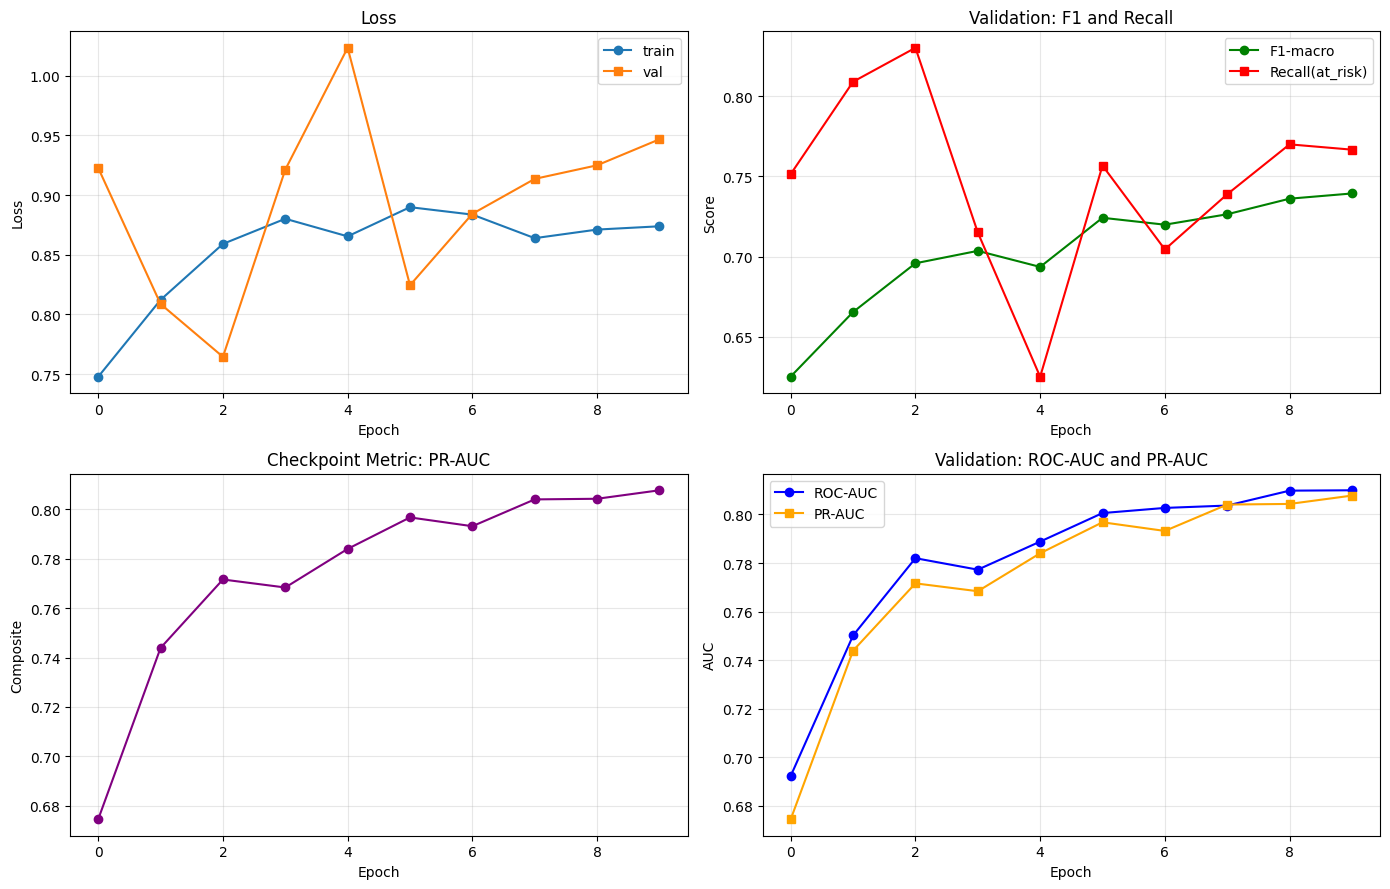

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(history['train_loss'], label='train', marker='o')
axes[0, 0].plot(history['val_loss'],   label='val',   marker='s')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history['val_f1'], color='green', marker='o', label='F1-macro')
axes[0, 1].plot(history['val_recall_fail'], color='red', marker='s', label='Recall(at_risk)')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Validation: F1 and Recall'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(history['val_composite'], color='purple', marker='o')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Composite')
axes[1, 0].set_title('Checkpoint Metric: PR-AUC')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(history['val_roc_auc'], color='blue', marker='o', label='ROC-AUC')
axes[1, 1].plot(history['val_pr_auc'], color='orange', marker='s', label='PR-AUC')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('AUC')
axes[1, 1].set_title('Validation: ROC-AUC and PR-AUC'); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


---
## Step 8. Error Analysis

### 8.1 False Negatives and False Positives Breakdown

**Purpose:** Address professor's feedback on detailed error analysis. Identify which maintenance types and conditions are systematically misclassified.


In [31]:
# Build test-set DataFrame with predictions
test_master_indices = seq_indices_used[idx_test]
test_pred_df = pd.DataFrame({
    'Master Index': test_master_indices,
    'y_true'      : test_result['labels'],
    'y_pred'      : test_result['preds'],
    'y_prob'      : test_result['probs'],
}).set_index('Master Index')

# Join with metadata from labels.csv (label, label_grouped, flight_length)
test_pred_df = test_pred_df.join(
    labels_df[['label', 'label_grouped', 'flight_length',
               'before_after', 'date_diff']],
    how='left'
)

# Flag error types
test_pred_df['error_type'] = 'TN'  # true negative (correctly safe)
test_pred_df.loc[(test_pred_df['y_true'] == 0) & (test_pred_df['y_pred'] == 0), 'error_type'] = 'TP'
test_pred_df.loc[(test_pred_df['y_true'] == 0) & (test_pred_df['y_pred'] == 1), 'error_type'] = 'FN'
test_pred_df.loc[(test_pred_df['y_true'] == 1) & (test_pred_df['y_pred'] == 0), 'error_type'] = 'FP'
test_pred_df.loc[(test_pred_df['y_true'] == 1) & (test_pred_df['y_pred'] == 1), 'error_type'] = 'TN'

print('Error type distribution:')
print(test_pred_df['error_type'].value_counts())
print()
print('Reminder:')
print('  TP: correctly flagged at-risk           (safety wins)')
print('  TN: correctly cleared safe              (operational efficiency)')
print('  FN: missed at-risk (SAFETY CRITICAL)    (would let dangerous aircraft fly)')
print('  FP: false alarm (unnecessary inspection)')


Error type distribution:
error_type
TP    1150
TN    1026
FP     396
FN     359
Name: count, dtype: int64

Reminder:
  TP: correctly flagged at-risk           (safety wins)
  TN: correctly cleared safe              (operational efficiency)
  FN: missed at-risk (SAFETY CRITICAL)    (would let dangerous aircraft fly)
  FP: false alarm (unnecessary inspection)


### 8.2 False Negatives by Maintenance Type

**Purpose:** Which types of failures does the model most often miss? Critical for understanding safety gaps.


False negatives broken down by maintenance type:
                                            total_at_risk  false_negatives  \
label_grouped                                                                
engine run rough                                       37               12   
baffle screw miss/loose                                48               15   
other                                                 319               97   
cylinder compression issue                             46               13   
rocker cover leak/loose/damage                        265               64   
baffle crack/damage/loose/miss                         69               16   
baffle plug need repair/replace                        69               15   
intake tube/bolt/seal/boot loose or damage             63               13   
baffle tie/tie rod loose or damage                     41                8   
intake gasket leak/damage                             514               99   
baffle seal loo

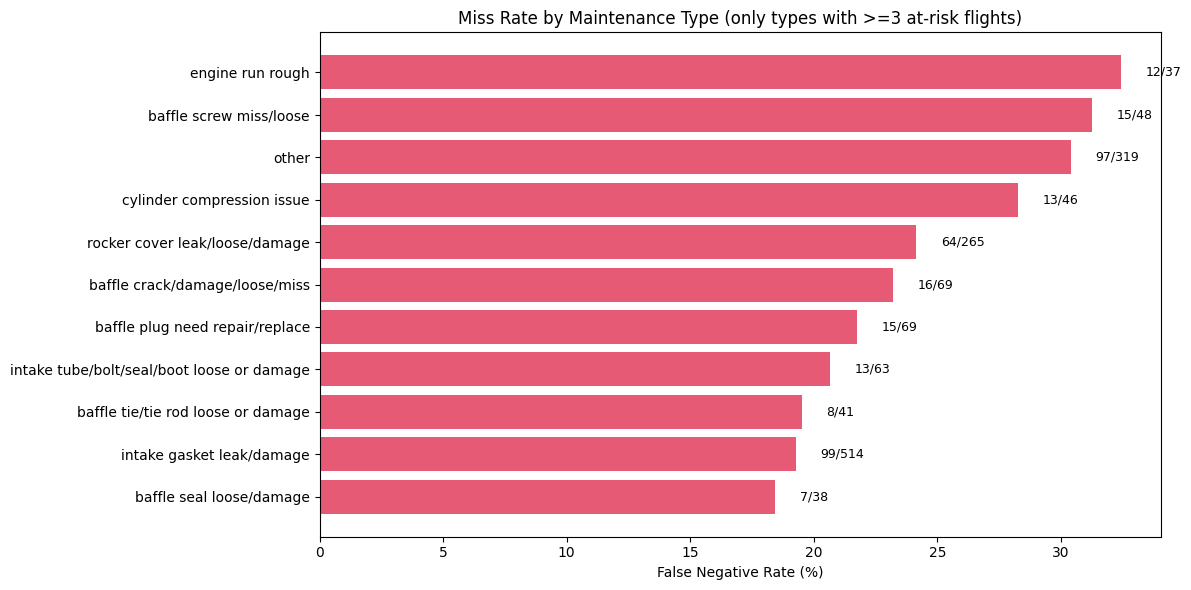

In [32]:
fn_by_label = test_pred_df[test_pred_df['error_type'] == 'FN']['label_grouped'].value_counts()
total_by_label = test_pred_df[test_pred_df['y_true'] == 0]['label_grouped'].value_counts()

fn_rate = (fn_by_label / total_by_label.reindex(fn_by_label.index).fillna(1)).fillna(0) * 100
fn_summary = pd.DataFrame({
    'total_at_risk' : total_by_label,
    'false_negatives' : fn_by_label,
    'miss_rate_%' : fn_rate,
}).fillna(0).sort_values('miss_rate_%', ascending=False)

print('False negatives broken down by maintenance type:')
print(fn_summary)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
fn_summary_plot = fn_summary[fn_summary['total_at_risk'] >= 3].head(15)
ax.barh(fn_summary_plot.index, fn_summary_plot['miss_rate_%'], color='crimson', alpha=0.7)
ax.set_xlabel('False Negative Rate (%)')
ax.set_title('Miss Rate by Maintenance Type (only types with >=3 at-risk flights)')
ax.invert_yaxis()
for i, (idx, row) in enumerate(fn_summary_plot.iterrows()):
    ax.text(row['miss_rate_%'] + 1, i,
            f'{int(row["false_negatives"])}/{int(row["total_at_risk"])}',
            va='center', fontsize=9)
plt.tight_layout(); plt.show()


### 8.3 Errors by Flight Length

**Purpose:** Does the model perform differently on short vs. long flights?


Error type proportion by flight length quartile (%):
error_type         FN    FP    TN    TP
length_quartile                        
Q1 (short)       10.8  17.2  24.6  47.5
Q2               12.5  12.3  38.3  36.9
Q3               12.3  11.6  39.1  36.9
Q4 (long)        13.4  13.0  38.1  35.6


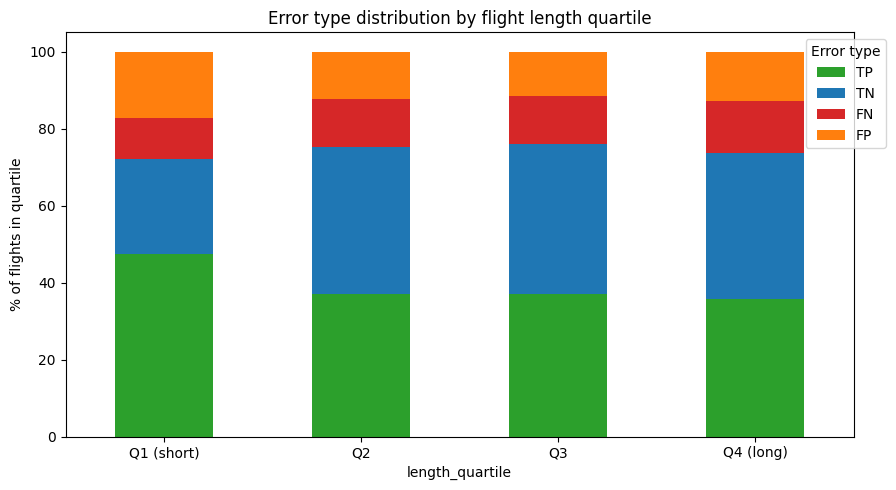

In [33]:
# Bin flight_length into quartiles
test_pred_df['length_quartile'] = pd.qcut(test_pred_df['flight_length'],
                                          q=4, labels=['Q1 (short)', 'Q2', 'Q3', 'Q4 (long)'],
                                          duplicates='drop')

err_by_length = pd.crosstab(test_pred_df['length_quartile'],
                            test_pred_df['error_type'],
                            normalize='index') * 100

print('Error type proportion by flight length quartile (%):')
print(err_by_length.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
err_by_length[['TP', 'TN', 'FN', 'FP']].plot(kind='bar', stacked=True, ax=ax,
                                              color=['#2ca02c', '#1f77b4', '#d62728', '#ff7f0e'])
ax.set_ylabel('% of flights in quartile')
ax.set_title('Error type distribution by flight length quartile')
ax.legend(title='Error type', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


### 8.4 Probability Distribution by Class

**Purpose:** How confident is the model in its predictions? Are probabilities well-calibrated?


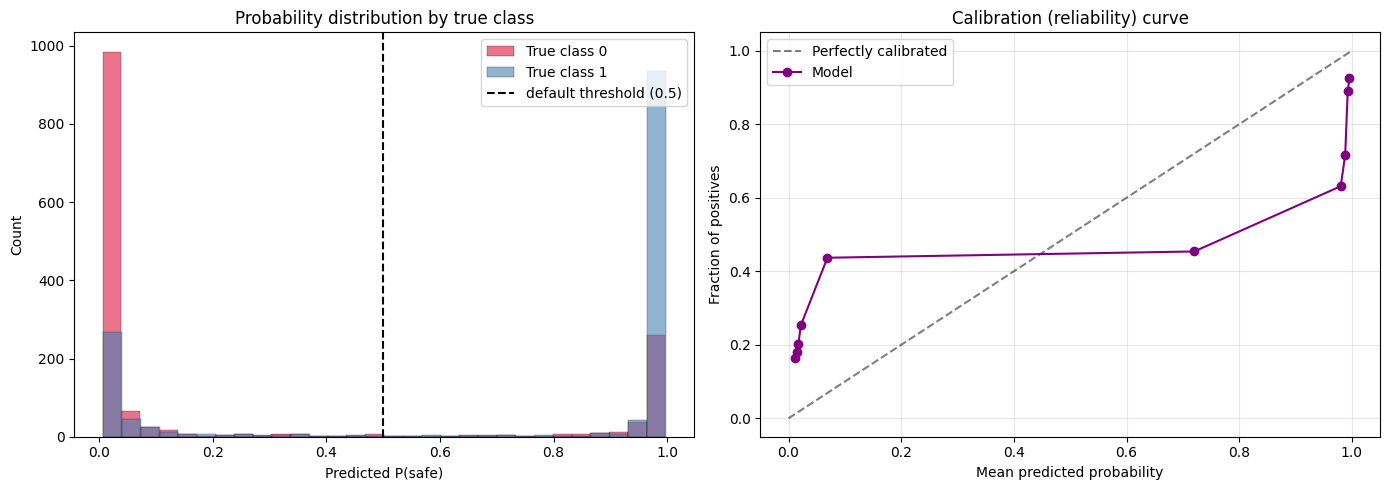

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Probability distribution by true class
for cls, color in [(0, 'crimson'), (1, 'steelblue')]:
    mask = test_pred_df['y_true'] == cls
    axes[0].hist(test_pred_df.loc[mask, 'y_prob'], bins=30, alpha=0.6,
                 label=f'True class {cls}', color=color, edgecolor='black', linewidth=0.3)
axes[0].axvline(0.5, color='black', ls='--', label='default threshold (0.5)')
axes[0].set_xlabel('Predicted P(safe)')
axes[0].set_ylabel('Count')
axes[0].set_title('Probability distribution by true class')
axes[0].legend()

# (b) Reliability curve (calibration)
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(test_pred_df['y_true'], test_pred_df['y_prob'],
                                          n_bins=10, strategy='quantile')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly calibrated')
axes[1].plot(prob_pred, prob_true, marker='o', color='purple', label='Model')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].set_title('Calibration (reliability) curve')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


---
## Step 9. Attention Visualization

**Purpose:** Show which timesteps the model focuses on. Required by professor's feedback on explainability.


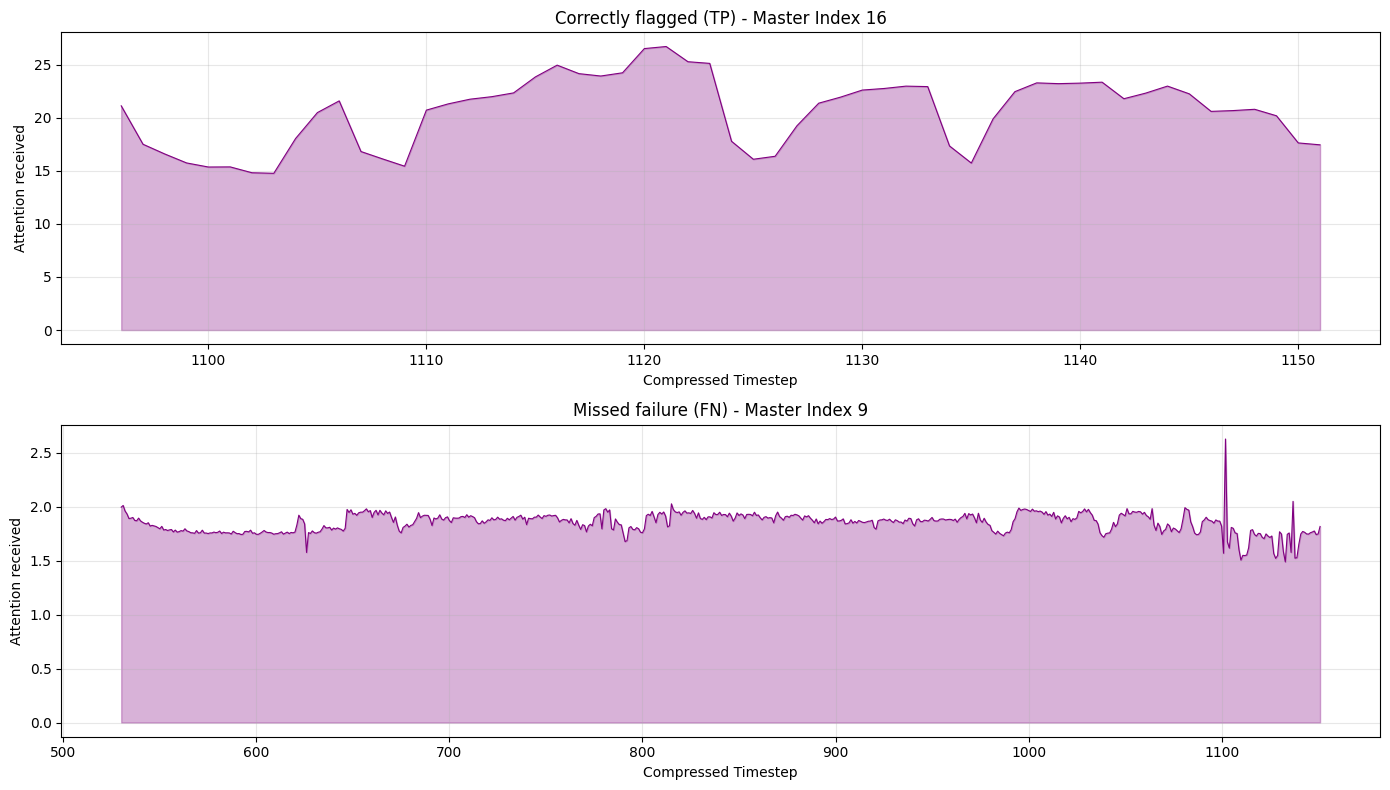

In [35]:
# Capture attention weights via forward hook on the first encoder layer
attention_weights = {}

def attention_hook(module, input, output):
    """PyTorch's MultiheadAttention returns (attn_output, attn_weights) when need_weights=True.
    But TransformerEncoderLayer wraps this. We patch the layer to extract weights."""
    pass  # placeholder, real extraction below

def get_attention_for_flight(model, x, mask):
    """Extract first-layer attention weights for a single flight."""
    model.eval()
    with torch.no_grad():
        # Run through conv frontend
        x_in = x.unsqueeze(0)  # (1, seq_len, channels)
        x_conv = x_in.transpose(1, 2)
        x_conv = model.conv_frontend(x_conv)
        x_conv = x_conv.transpose(1, 2)  # (1, reduced_seq, d_model)

        reduced_seq = x_conv.shape[1]
        x_pos = x_conv + model.pos_encoder[:, :reduced_seq, :]

        # Downsample mask
        down_mask = nn.functional.interpolate(
            mask.unsqueeze(0).unsqueeze(1).float(),
            size=reduced_seq, mode='nearest'
        ).squeeze(1)
        kpm = (down_mask == 0.0)

        # Get attention from first encoder layer
        first_layer = model.transformer_encoder.layers[0]
        attn_out, attn_weights = first_layer.self_attn(
            x_pos, x_pos, x_pos,
            key_padding_mask=kpm,
            need_weights=True,
            average_attn_weights=True
        )
        return attn_weights.squeeze(0).cpu().numpy()


# Pick one correctly-classified at-risk flight and one missed at-risk flight
correctly_at_risk = test_pred_df[test_pred_df['error_type'] == 'TP'].head(1)
missed_at_risk    = test_pred_df[test_pred_df['error_type'] == 'FN'].head(1)

flights_to_viz = []
if len(correctly_at_risk) > 0:
    flights_to_viz.append(('Correctly flagged (TP)', correctly_at_risk.index[0]))
if len(missed_at_risk) > 0:
    flights_to_viz.append(('Missed failure (FN)', missed_at_risk.index[0]))

fig, axes = plt.subplots(len(flights_to_viz), 1, figsize=(14, 4 * max(len(flights_to_viz), 1)))
if len(flights_to_viz) == 1:
    axes = [axes]

for ax, (title, master_idx) in zip(axes, flights_to_viz):
    local_pos = np.where(seq_indices_used == master_idx)[0][0]
    mmap_pos = sequence_positions[local_pos]
    seq = torch.tensor(np.array(sequences[mmap_pos]), dtype=torch.float32).to(device)
    msk = torch.zeros(SEQ_LEN, dtype=torch.float32).to(device)
    nonzero = (seq != 0).any(dim=1).cpu().numpy()
    if nonzero.any():
        first_real = int(np.argmax(nonzero))
        msk[first_real:] = 1.0
    
    try:
        attn = get_attention_for_flight(model, seq, msk)
        attention_received = attn.sum(axis=0)
        n_steps = len(attention_received)
        
        # Build a mask for the compressed sequence for plotting
        down_mask_np = nn.functional.interpolate(
            msk.unsqueeze(0).unsqueeze(1).float(),
            size=n_steps, mode='nearest'
        ).squeeze().cpu().numpy().astype(bool)
        
        ax.plot(np.arange(n_steps)[down_mask_np], attention_received[down_mask_np],
                color='purple', linewidth=0.8)
        ax.fill_between(np.arange(n_steps), 0, attention_received,
                       where=down_mask_np, alpha=0.3, color='purple')
        ax.set_title(f'{title} - Master Index {master_idx}')
        ax.set_xlabel('Compressed Timestep')
        ax.set_ylabel('Attention received')
        ax.grid(alpha=0.3)
    except Exception as e:
        ax.text(0.5, 0.5, f'Attention extraction failed: {e}',
                ha='center', va='center', transform=ax.transAxes)

plt.tight_layout(); plt.show()


---
## Step 10. Save Artifacts for Handoff


In [36]:
import json
from pathlib import Path

OUT_DIR = Path('/kaggle/working/transformer_artifacts')
OUT_DIR.mkdir(exist_ok=True)

# Save best model state
torch.save(model.state_dict(), OUT_DIR / 'best_model.pt')

# Save test predictions for downstream analysis
test_pred_df.to_csv(OUT_DIR / 'test_predictions.csv')

# Save config + metrics
config = {
    'run_mode'        : RUN_MODE,
    'target_variable' : TARGET_VARIABLE,
    'n_channels'      : N_CHANNELS,
    'channel_names'   : CHANNEL_NAMES,
    'seq_len'         : SEQ_LEN,
    'n_classes'       : N_CLASSES,
    'd_model'         : D_MODEL,
    'n_head'          : N_HEAD,
    'num_layers'      : NUM_LAYERS,
    'dim_feedforward' : DIM_FEEDFORWARD,
    'dropout'         : DROPOUT,
    'batch_size'      : BATCH_SIZE,
    'n_epochs'        : N_EPOCHS,
    'lr'              : LR,
    'checkpoint_metric': 'pr_auc',
    'best_val_composite' : float(best_composite),
    'best_epoch'         : int(best_epoch),
    'test_accuracy'      : float(test_result['accuracy']),
    'test_f1_macro'      : float(test_result['f1_macro']),
    'test_recall_at_risk': float(test_result['recall_per_class'][0]),
    'test_precision_at_risk': float(test_result['precision_per_class'][0]),
    'test_roc_auc'   : float(test_result['roc_auc']) if not np.isnan(test_result['roc_auc']) else None,
    'test_pr_auc'    : float(test_result['pr_auc']) if not np.isnan(test_result['pr_auc']) else None,
    'inference_ms_per_flight': float(test_result['inference_ms_per_flight']),
}
with open(OUT_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'Artifacts saved to {OUT_DIR.resolve()}/')
print(f'  best_model.pt          : model weights')
print(f'  test_predictions.csv   : per-flight predictions and errors')
print(f'  config.json            : hyperparameters and final metrics')
print()
print(json.dumps(config, indent=2))


Artifacts saved to /kaggle/working/transformer_artifacts/
  best_model.pt          : model weights
  test_predictions.csv   : per-flight predictions and errors
  config.json            : hyperparameters and final metrics

{
  "run_mode": "full",
  "target_variable": "rul_5d",
  "n_channels": 15,
  "channel_names": [
    "volt1",
    "amp1",
    "FQtyL",
    "FQtyR",
    "E1 FFlow",
    "E1 OilT",
    "E1 OilP",
    "E1 RPM",
    "E1 CHT1",
    "E1 EGT1",
    "OAT",
    "IAS",
    "VSpd",
    "NormAc",
    "AltMSL"
  ],
  "seq_len": 9212,
  "n_classes": 2,
  "d_model": 256,
  "n_head": 8,
  "num_layers": 4,
  "dim_feedforward": 1024,
  "dropout": 0.1,
  "batch_size": 2,
  "n_epochs": 10,
  "lr": 3e-05,
  "checkpoint_metric": "pr_auc",
  "best_val_composite": 0.8077871039079367,
  "best_epoch": 10,
  "test_accuracy": 0.7424087342204025,
  "test_f1_macro": 0.7419468630271411,
  "test_recall_at_risk": 0.7620941020543406,
  "test_precision_at_risk": 0.7438551099611902,
  "test_roc_auc": 0.8

Save best result and parameters for each target_variable.

In [37]:
import shutil
shutil.move('/kaggle/working/transformer_artifacts', 
            f'/kaggle/working/transformer_artifacts_{TARGET_VARIABLE}')
print(f'Saved to transformer_artifacts_{TARGET_VARIABLE}/')

Saved to transformer_artifacts_rul_5d/


In [38]:
# Zip everything for easy download
!zip -r /kaggle/working/all_results.zip /kaggle/working/transformer_artifacts_rul_*

  adding: kaggle/working/transformer_artifacts_rul_5d/ (stored 0%)
  adding: kaggle/working/transformer_artifacts_rul_5d/config.json (deflated 47%)
  adding: kaggle/working/transformer_artifacts_rul_5d/best_model.pt (deflated 8%)
  adding: kaggle/working/transformer_artifacts_rul_5d/test_predictions.csv (deflated 85%)
